### Loading & Testing NLP Model

### Reproducibility setup

This notebook is designed to run from either the repository root or the `src/` folder. By default it uses the cached SQLite database in `data/articles.db`, which keeps the results stable even if APIs, webpages, or model downloads change later. Live collection, article scraping, and model recomputation are controlled by switches in the next cell.

In [1]:
from pathlib import Path
import os
import random
import sqlite3

import numpy as np
import pandas as pd

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# Resolve paths robustly whether the notebook is launched from the repo root or from src/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "src" else CWD
DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "articles.db"

# Stable analysis window. yfinance treats the end date as exclusive.
START_DATE = "2025-01-01"
END_DATE = "2026-05-02"

# Reproducibility switches. The cached DB already contains article metadata and sentiment scores.
USE_LIVE_ARTICLE_COLLECTION = False
RUN_ARTICLE_BODY_SCRAPING = False
RECOMPUTE_MISSING_FINBERT = False

GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY", "")
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "")
NYT_API_KEY = os.getenv("NYT_API_KEY", "")

random.seed(42)
np.random.seed(42)

print(f"Project root: {PROJECT_ROOT}")
print(f"Database path: {DB_PATH}")
print(f"Cached database exists: {DB_PATH.exists()}")

Project root: C:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project
Database path: C:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project\data\articles.db
Cached database exists: True


In [2]:
import requests
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import json
import pandas as pd

In [3]:
try:
    nlp = spacy.load("en_core_web_md")
    print("Loaded spaCy model: en_core_web_md")
except OSError:
    try:
        nlp = spacy.load("en_core_web_sm")
        print("Loaded fallback spaCy model: en_core_web_sm")
    except OSError:
        nlp = spacy.blank("en")
        print("No installed spaCy model found; using blank English pipeline for reproducibility.")

Loaded spaCy model: en_core_web_md


In [ ]:
if "spacytextblob" not in nlp.pipe_names:
    nlp.add_pipe("spacytextblob")

doc = nlp("Argentina faces severe economic crisis")
print(doc._.blob.polarity)  

0.2


### Creating & Populating the Database

In [5]:
import sqlite3
from pathlib import Path

DATA_DIR.mkdir(parents=True, exist_ok=True)

def create_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS articles (
        article_id TEXT PRIMARY KEY,
        country TEXT,
        date TEXT,
        source_name TEXT,
        title TEXT,
        description TEXT,
        url TEXT,
        published_at TEXT
    )
    """)

    conn.commit()
    return conn, cursor

conn, cursor = create_database(DB_PATH)
print(f"Using database: {DB_PATH}")

Using database: C:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project\data\articles.db


In [6]:

def insert_articles(cursor, conn, articles):

    inserted = 0

    for a in articles:

        cursor.execute("""
            INSERT OR IGNORE INTO articles (
                article_id,
                country,
                date,
                source_name,
                title,
                description,
                url,
                published_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            a["article_id"],
            a["country"],
            a["date"],
            a["source_name"],
            a["title"],
            a["description"],
            a["url"],
            a["published_at"]
        ))

        inserted += cursor.rowcount

    conn.commit()

    print(f"  Inserted into DB: {inserted}")

In [7]:
#guardian
import requests

def fetch_guardian(country, begin_date, end_date, api_key):

    print("\nGUARDIAN FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("Missing Guardian API key")
        return []

    url = "https://content.guardianapis.com/search"

    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "from-date": begin_date,
            "to-date": end_date,
            "page-size": 200,
            "order-by": "newest",
            "show-fields": "headline,trailText",
            "api-key": api_key
        }

        print(f"  Query: {q}")

        response = requests.get(url, params=params)

        print(f"  Status code: {response.status_code}")

        if response.status_code != 200:
            print(" request failed")
            print(response.text)
            continue

        try:
            data = response.json()
        except Exception as e:
            print(f" JSON decode error: {e}")
            continue

        results = data.get("response", {}).get("results", [])

        print(f"  Articles returned: {len(results)}")

        for article in results:

            fields = article.get("fields", {})
            published_at = article.get("webPublicationDate")

            all_articles.append({
                "article_id": article.get("id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "The Guardian",
                "title": fields.get("headline"),
                "description": fields.get("trailText"),
                "url": article.get("webUrl"),
                "published_at": published_at
            })

    return all_articles

In [8]:
#news
import requests

NEWSAPI_ENDPOINT = "https://newsapi.org/v2/everything"

def fetch_newsapi(country, date_str, api_key):

    print("\n NEWSAPI FETCH START")
    print(f"   Country: {country}")
    print(f"   Date: {date_str}")

    if not api_key:
        print(" Missing NewsAPI key")
        return []

    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth",
        f"{country} central bank",
        f"{country} fiscal policy"
    ]

    all_articles = []

    for query in queries:

        params = {
            "q": query,
            "from": date_str,
            "to": date_str,
            "language": "en",
            "sortBy": "publishedAt",  
            "pageSize": 50,
            "apiKey": api_key
        }

        print(f"  Query: {query}")

        response = requests.get(NEWSAPI_ENDPOINT, params=params)

        if response.status_code != 200:
            print(f"  Error: {response.text}")
            continue

        data = response.json()
        articles = data.get("articles", [])

        print(f"  Returned: {len(articles)}")

        for i, a in enumerate(articles):

            all_articles.append({
                "article_id": f"newsapi_{country}_{date_str}_{query}_{i}",
                "country": country,
                "date": date_str,
                "source_name": a.get("source", {}).get("name"),
                "title": a.get("title"),
                "description": a.get("description"),
                "url": a.get("url"),
                "published_at": a.get("publishedAt")
            })

    return all_articles

In [9]:
#nyt
import requests

def fetch_nyt(country, begin_date, end_date, api_key):

    print("\n NYT FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print(" Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    params = {
        "q": f"{country} (economy OR GDP OR inflation OR growth OR macro OR fiscal OR monetary)",
        "begin_date": begin_date,
        "end_date": end_date,
        "sort": "newest",
        "api-key": api_key
    }

    print(f"  Requesting NYT API...")

    response = requests.get(url, params=params)

    print(f" Status code: {response.status_code}")


    if response.status_code == 429:
        print("  RATE LIMITED — skipping request")
        return []


    if response.status_code != 200:
        print("   Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"  JSON decode error: {e}")
        return []

    docs = data.get("response", {}).get("docs", [])

    if docs is None:
        docs = []

    print(f"  Articles returned: {len(docs)}")

    articles = []

    for doc in docs:

        published_at = doc.get("pub_date")

        article = {
            "article_id": doc.get("_id"),

            "country": country,

        
            "date": published_at[:10] if published_at else None,

            "source_name": "New York Times",

            "title": doc.get("headline", {}).get("main"),

            "description": doc.get("abstract"),

            "url": doc.get("web_url"),

            "published_at": published_at
        }

        articles.append(article)

    print(f"   Parsed articles: {len(articles)}")

    return articles

In [10]:
import sqlite3
from pathlib import Path

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [11]:
import requests
import time

def safe_request(url, params, retries=3):

    for i in range(retries):
        try:
            response = requests.get(url, params=params, timeout=15)

        
            if response.status_code == 429:
                print("Rate limited (429). Sleeping...")
                time.sleep(5)
                continue

            return response

        except requests.exceptions.SSLError:
            print(f"SSL error (attempt {i+1}) — retrying...")
            time.sleep(2)

        except requests.exceptions.RequestException as e:
            print(f"Request error (attempt {i+1}): {e}")
            time.sleep(2)

    return None


def fetch_nyt(country, begin_date, end_date, api_key):

    print("\nNYT FETCH START")
    print(f"Country: {country}")

    if not api_key:
        print("Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"


    queries = [
        f"{country} economy",
        f"{country} GDP",
        f"{country} inflation",
        f"{country} growth"
    ]

    all_articles = []

    for q in queries:

        params = {
            "q": q,
            "begin_date": begin_date,
            "end_date": end_date,
            "sort": "newest",
            "api-key": api_key
        }

        print(f" Query: {q}")

        response = safe_request(url, params)

        if response is None:
            print("Request failed after retries")
            continue

        if response.status_code != 200:
            print(f"Error {response.status_code}: {response.text}")
            continue

        data = response.json()
        docs = data.get("response", {}).get("docs", [])

        print(f" Articles returned: {len(docs)}")

        for doc in docs:

            published_at = doc.get("pub_date")

            all_articles.append({
                "article_id": doc.get("_id"),
                "country": country,
                "date": published_at[:10] if published_at else None,
                "source_name": "New York Times",
                "title": doc.get("headline", {}).get("main"),
                "description": doc.get("abstract"),
                "url": doc.get("web_url"),
                "published_at": published_at
            })

      
        time.sleep(1)

    return all_articles

### Optional live article collection

The cached database is the reproducible version used for the analysis. Set `USE_LIVE_ARTICLE_COLLECTION = True` in the setup cell if you want to extend or rebuild the database using API keys from `.env`.

In [12]:
if USE_LIVE_ARTICLE_COLLECTION:
    countries_to_fetch = ["Turkey", "India", "Vietnam", "Argentina", "Indonesia", "Nigeria"]
    begin_date = START_DATE
    end_date = END_DATE.replace("-", "")

    for country in countries_to_fetch:
        guardian_articles = fetch_guardian(country, START_DATE, END_DATE[:10], GUARDIAN_API_KEY)
        nyt_articles = fetch_nyt(country, begin_date.replace("-", ""), end_date, NYT_API_KEY)
        insert_articles(cursor, conn, guardian_articles + nyt_articles)
else:
    print("Live collection is disabled; using the cached SQLite database.")

Live collection is disabled; using the cached SQLite database.


### Querying the SQLite Database

In [13]:
conn = sqlite3.connect(DB_PATH)

query = "SELECT DISTINCT country FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

     country
0  Argentina
1      India
2  Indonesia
3    Nigeria
4     Turkey
5    Vietnam


In [14]:
conn = sqlite3.connect(DB_PATH)

query = "SELECT * FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

                                            article_id  country        date  \
0    business/live/2026/jan/02/uk-house-prices-drop...    India  2026-01-02   
1    business/2026/jan/06/jaguar-land-rover-sales-u...    India  2026-01-06   
2    business/live/2026/jan/06/jlr-sales-hit-by-cyb...    India  2026-01-06   
3    business/2026/jan/06/bank-of-england-venezuela...  Vietnam  2026-01-06   
4    business/2026/jan/08/shadow-fleet-ships-sancti...   Turkey  2026-01-08   
..                                                 ...      ...         ...   
574                   b91d3ab7ecea495c8dd65a57d39478db   Turkey  2026-04-22   
575                   ba0d9b11ffce9d8c9bf44b88eb4d0005   Turkey  2026-04-22   
576                   91a0820849226ce7191a4dcfe6894603   Turkey  2026-04-22   
577                   1b82a58fba64c0b5328abf4c7e21e21c   Turkey  2026-04-22   
578                   2949e8137d60035ef4e7ecbab5ce8f2d   Turkey  2026-04-22   

      source_name                                  

In [15]:

conn = sqlite3.connect(DB_PATH)

table_name = "articles"

query = f"""
PRAGMA table_info({table_name});
"""

df_columns = pd.read_sql_query(query, conn)

print(df_columns)

conn.close()

    cid                        name  type  notnull dflt_value  pk
0     0                  article_id  TEXT        0       None   1
1     1                     country  TEXT        0       None   0
2     2                        date  TEXT        0       None   0
3     3                 source_name  TEXT        0       None   0
4     4                       title  TEXT        0       None   0
5     5                 description  TEXT        0       None   0
6     6                         url  TEXT        0       None   0
7     7                published_at  TEXT        0       None   0
8     8             sentiment_score  REAL        0       None   0
9     9       sentiment_score_vader  REAL        0       None   0
10   10     sentiment_score_finbert  REAL        0       None   0
11   11                article_text  TEXT        0       None   0
12   12  sentiment_fulltext_finbert  REAL        0       None   0


In [16]:
import sqlite3
import pandas as pd
from textblob import TextBlob

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_vader REAL
    """)
    conn.commit()
    print("TextBlob sentiment column created.")
except sqlite3.OperationalError:
    print("TextBlob sentiment column already exists.")

df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
WHERE title IS NOT NULL
  AND sentiment_score_vader IS NULL
""", conn)

def sentiment_textblob(text):
    if pd.isna(text):
        return None
    return TextBlob(text).sentiment.polarity

if df_articles.empty:
    print("No missing TextBlob headline sentiment scores to compute.")
else:
    updates = [
        (sentiment_textblob(row["title"]), row["article_id"])
        for _, row in df_articles.iterrows()
    ]
    cursor.executemany("""
    UPDATE articles
    SET sentiment_score_vader = ?
    WHERE article_id = ?
    """, updates)
    conn.commit()
    print(f"Updated {len(updates)} TextBlob sentiment scores.")

df_vader = pd.read_sql_query("""
SELECT title, sentiment_score_vader, date, country
FROM articles
""", conn)

print(df_vader.head())
conn.close()

TextBlob sentiment column already exists.
No missing TextBlob headline sentiment scores to compute.
                                               title  sentiment_score_vader  \
0  FTSE 100 hits 10,000 point milestone for first...                  0.625   
1  Jaguar Land Rover sales slump sharply amid US ...                 -0.125   
2  FTSE 100 posts best day in six months as stock...                  1.000   
3  Deep in the vaults: the Bank of England’s £1.4...                  0.000   
4  ‘Shadow fleet’ ships moving sanctioned oil ref...                  0.000   

         date  country  
0  2026-01-02    India  
1  2026-01-06    India  
2  2026-01-06    India  
3  2026-01-06  Vietnam  
4  2026-01-08   Turkey  


In [17]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH, timeout=30)
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score_finbert REAL
    """)
    conn.commit()
except sqlite3.OperationalError:
    pass

df_articles = pd.read_sql_query("""
SELECT article_id, title
FROM articles
WHERE title IS NOT NULL
  AND sentiment_score_finbert IS NULL
""", conn)

if df_articles.empty:
    print("No missing FinBERT headline sentiment scores to compute.")
elif not RECOMPUTE_MISSING_FINBERT:
    print(f"{len(df_articles)} missing FinBERT headline scores found, but recomputation is disabled.")
else:
    from transformers import pipeline
    finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

    def finbert_signed(text):
        result = finbert(text)[0]
        label = result["label"]
        score = result["score"]
        return score if label == "positive" else -score if label == "negative" else 0.0

    df_articles["sentiment_score_finbert"] = df_articles["title"].apply(finbert_signed)

    cursor.executemany("""
    UPDATE articles
    SET sentiment_score_finbert = ?
    WHERE article_id = ?
    """, list(zip(
        df_articles["sentiment_score_finbert"],
        df_articles["article_id"]
    )))

    conn.commit()
    print(f"Updated {len(df_articles)} FinBERT headline sentiment scores.")

conn.close()

No missing FinBERT headline sentiment scores to compute.


In [18]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

df_finbert["date"] = pd.to_datetime(df_finbert["date"])

df_finbert.head()

,date,country,sentiment_score_finbert
0,2026-01-02,India,0.879452
1,2026-01-06,India,-0.973458
2,2026-01-06,India,0.723519
3,2026-01-06,Vietnam,0.000000
4,2026-01-08,Turkey,0.000000


In [19]:
countries = ["Turkey", "India", "Indonesia", "Argentina"]

df_plot = df_finbert[df_finbert["country"].isin(countries)]

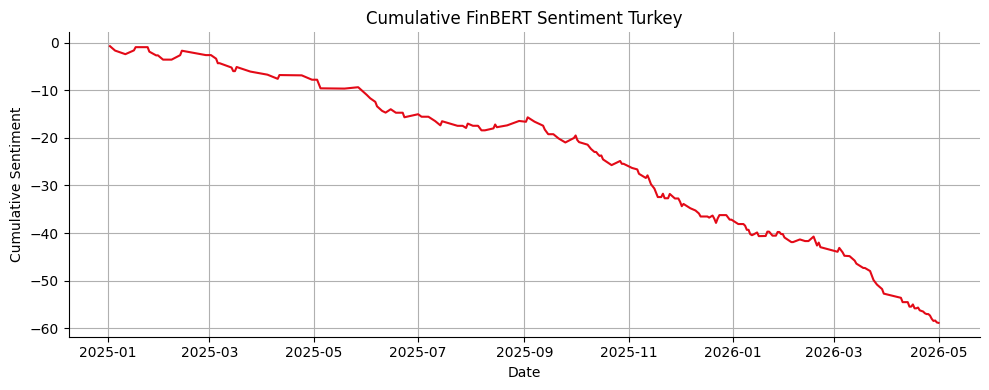

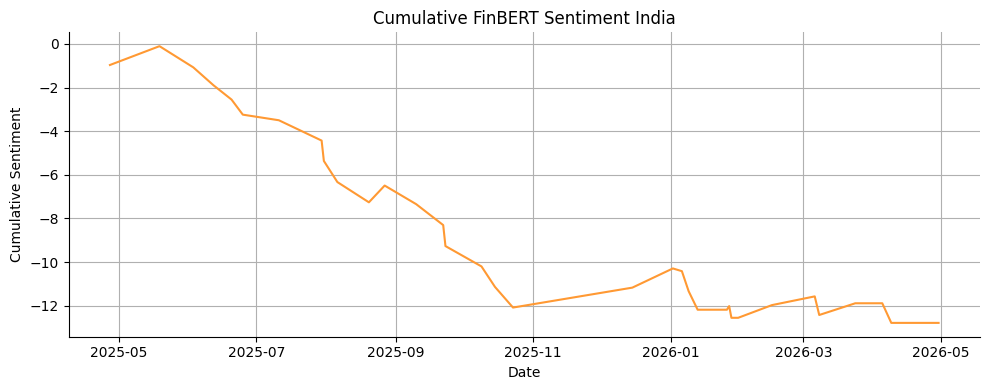

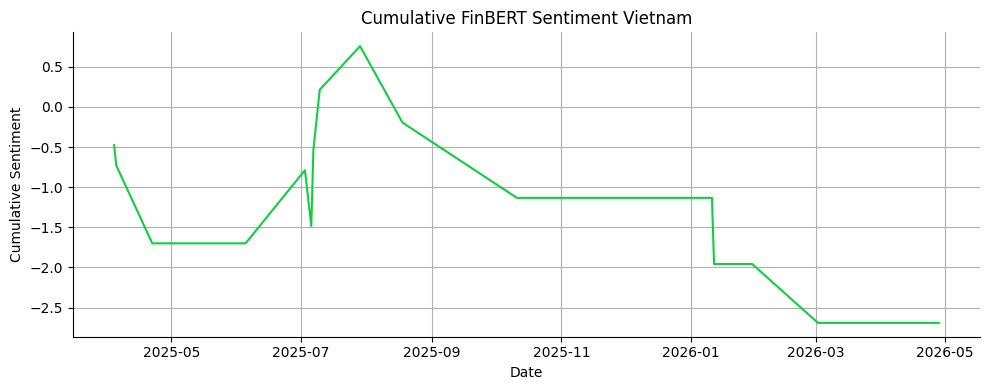

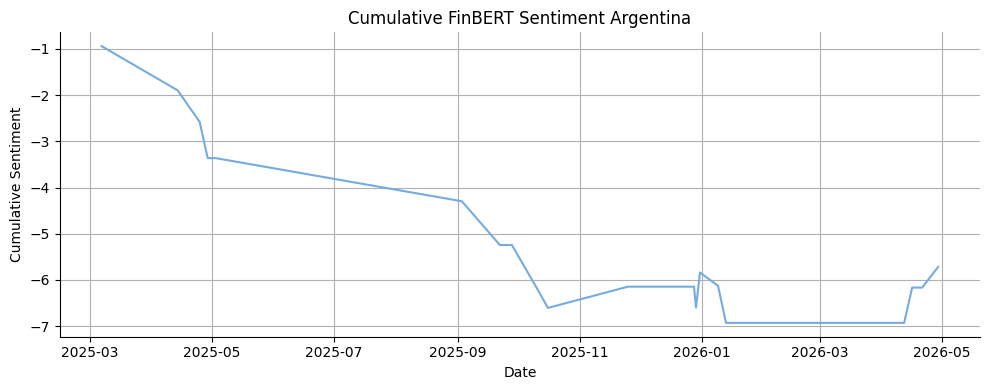

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# LOAD DATA
conn = sqlite3.connect(DB_PATH)

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()

# CLEAN DATA
df_finbert["date"] = pd.to_datetime(df_finbert["date"])

# COLOUR MAP
colors = {
    "Turkey": "#E30A17",
    "Vietnam": "#11CE40",
    "India": "#FF9933",
    "Argentina": "#74ACDF"
}

countries = ["Turkey", "India", "Vietnam", "Argentina"]


for country in countries:

    subset = df_finbert[df_finbert["country"] == country]

    # daily average sentiment
    daily = subset.groupby("date")["sentiment_score_finbert"].mean()


    cumulative = daily.cumsum()

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        cumulative.index,
        cumulative.values,
        color=colors[country]
    )

    ax.set_title(f"Cumulative FinBERT Sentiment {country}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Sentiment")

    ax.grid(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

In [21]:
df_vader

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


In [22]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

In [23]:
df_plot["date"] = pd.to_datetime(df_plot["date"])

In [24]:
df_plot.dtypes

date                       datetime64[us]
country                               str
sentiment_score_finbert           float64
dtype: object

Saved market price cache to C:\Users\alice\Desktop\Uni\Econ\Data science for Econ\Final Project\data\market_prices.csv


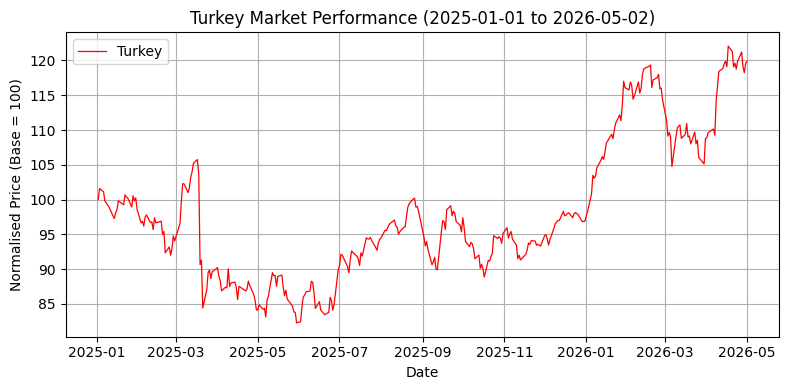

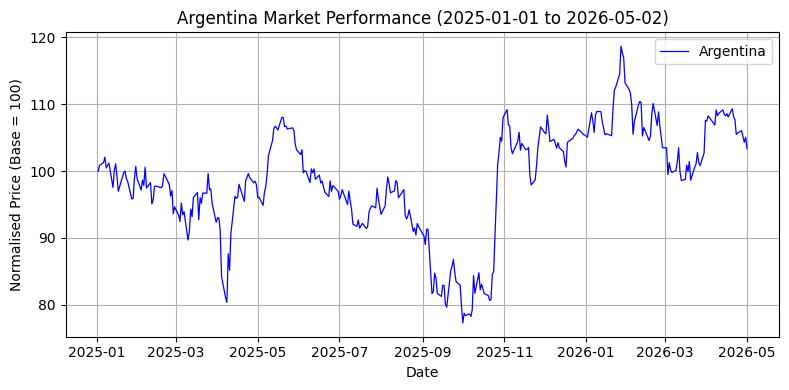

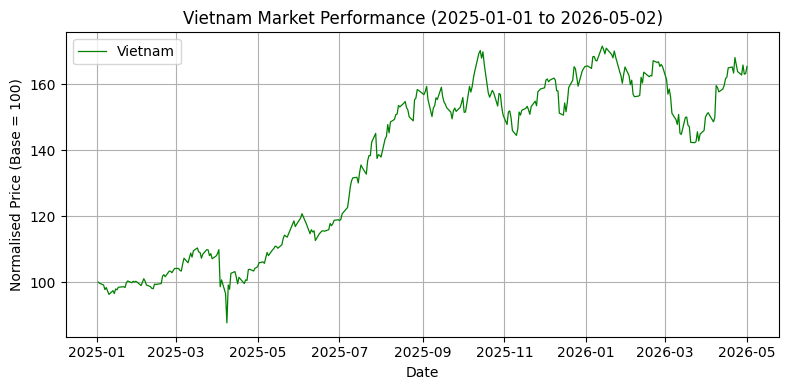

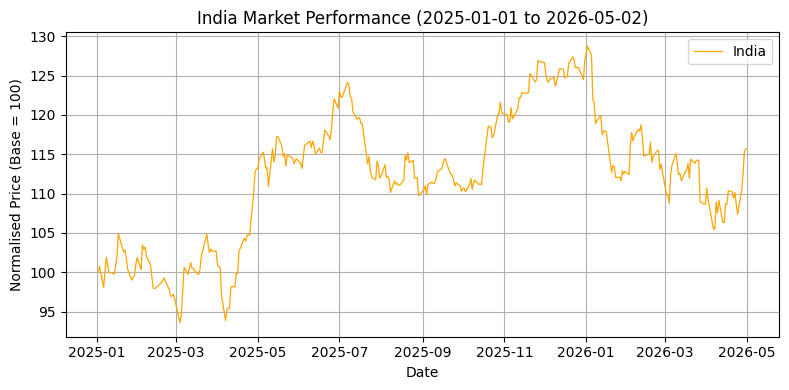

In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = {
    "Turkey": "TUR",
    "Argentina": "ARGT",
    "Vietnam": "VNM",
    "India": "RELIANCE.NS"
}

market_cache = DATA_DIR / "market_prices.csv"

if market_cache.exists():
    data = pd.read_csv(market_cache, parse_dates=["Date"]).set_index("Date")
    print(f"Loaded cached market prices from {market_cache}")
else:
    data = pd.DataFrame()

    for name, ticker in tickers.items():
        print(f"Downloading {ticker}...")

        try:
            df = yf.download(
                ticker,
                start=START_DATE,
                end=END_DATE,
                progress=False,
                timeout=10,
                auto_adjust=False
            )

            if df.empty:
                print(f"No data for {ticker}")
                continue

            if "Adj Close" in df.columns:
                data[name] = df["Adj Close"]
            else:
                data[name] = df["Close"]

        except Exception as e:
            print(f"Failed for {ticker}: {e}")

    if data.empty:
        raise ValueError("No market data downloaded and no cached market_prices.csv was found.")

    data = data.ffill()
    data.to_csv(market_cache, index_label="Date")
    print(f"Saved market price cache to {market_cache}")

normalized = data / data.iloc[0] * 100

colors = {
    "Turkey": "red",
    "Argentina": "blue",
    "Vietnam": "green",
    "India": "orange"
}

for country in normalized.columns:
    plt.figure(figsize=(8, 4))

    plt.plot(
        normalized.index,
        normalized[country],
        color=colors[country],
        label=country,
        linewidth=0.9
    )

    plt.title(f"{country} Market Performance ({START_DATE} to {END_DATE})")
    plt.xlabel("Date")
    plt.ylabel("Normalised Price (Base = 100)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

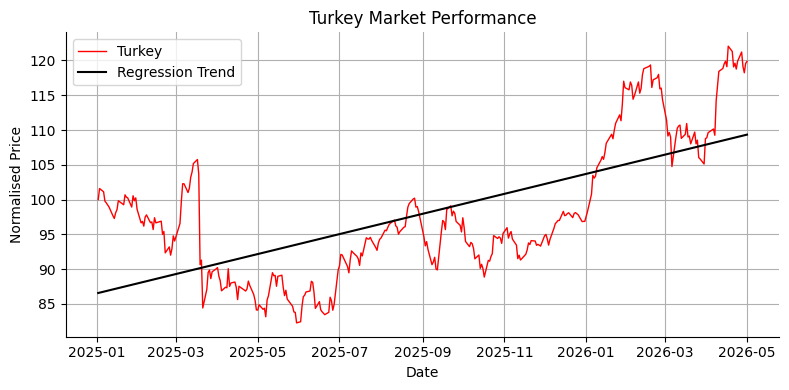

Turkey slope: 0.047038


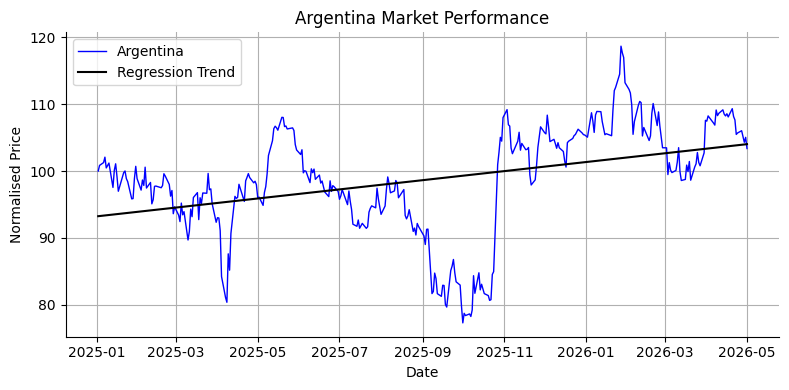

Argentina slope: 0.022261


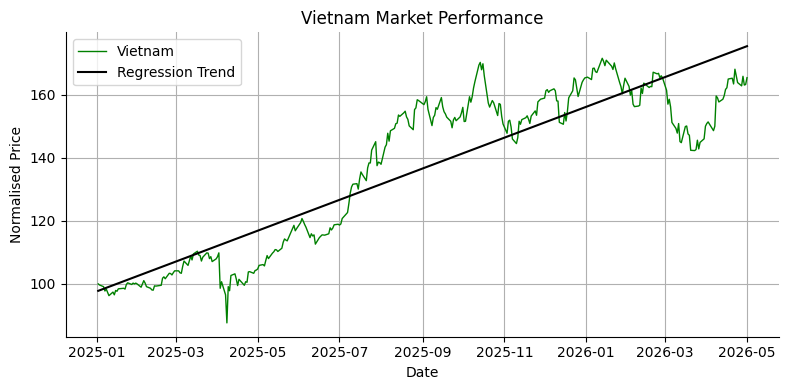

Vietnam slope: 0.160496


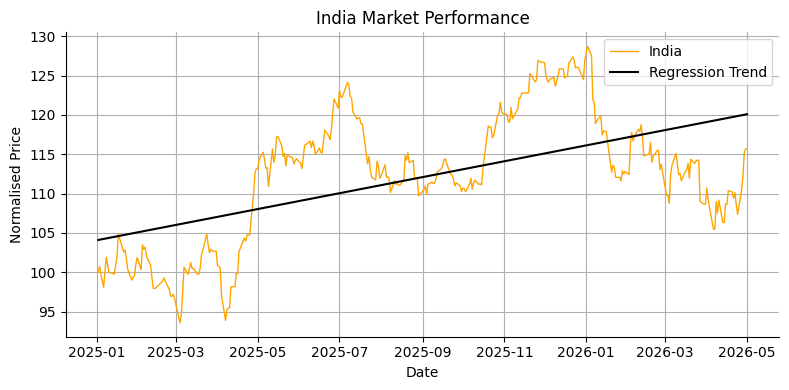

India slope: 0.033025


In [26]:
import numpy as np
import matplotlib.pyplot as plt

for country in normalized.columns:

    fig, ax = plt.subplots(figsize=(8, 4))


    x_dates = normalized.index

    # convert dates -> numeric
    x_numeric = x_dates.map(pd.Timestamp.toordinal)

    y = normalized[country]

 
    slope, intercept = np.polyfit(x_numeric, y, 1)

    trend_line = slope * x_numeric + intercept

    
    ax.plot(
        x_dates,
        y,
        color=colors[country],
        linewidth=1,
        label=f"{country}"
    )

    ax.plot(
        x_dates,
        trend_line,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Regression Trend"
    )

    
    ax.set_title(f"{country} Market Performance")
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalised Price")

    ax.legend()
    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


    print(f"{country} slope: {slope:.6f}")

In [27]:
try:
    finbert
except NameError:
    if RECOMPUTE_MISSING_FINBERT:
        from transformers import pipeline
        finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")
    else:
        finbert = None
        print("FinBERT model is not loaded because cached sentiment scores are being used.")

FinBERT model is not loaded because cached sentiment scores are being used.


In [28]:
if finbert is not None:
    result = finbert("Turkey inflation falls faster than expected")
    print(result)
else:
    print("Skipped live FinBERT example; cached sentiment scores are used for the analysis.")

Skipped live FinBERT example; cached sentiment scores are used for the analysis.


In [29]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

query = "SELECT title FROM articles LIMIT 10"
df_test_finbert = pd.read_sql_query(query, conn)
print(df_test_finbert, "\n")

if finbert is not None:
    for rows in df_test_finbert["title"]:
        print(rows)
        print(finbert(rows))
        print("\n")
else:
    print("Skipped live FinBERT title test; cached sentiment scores are used for the analysis.")

conn.close()

                                               title
0  FTSE 100 hits 10,000 point milestone for first...
1  Jaguar Land Rover sales slump sharply amid US ...
2  FTSE 100 posts best day in six months as stock...
3  Deep in the vaults: the Bank of England’s £1.4...
4  ‘Shadow fleet’ ships moving sanctioned oil ref...
5  Pub chain shares rise on reports of government...
6  US economy added fewer jobs than forecast in D...
7  High costs, falling returns: what could go wro...
8  Why Russia’s economy is unlikely to collapse e...
9  Trump move for Venezuela’s resources likely to... 

Skipped live FinBERT title test; cached sentiment scores are used for the analysis.


In [30]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute("PRAGMA table_info(articles)")

for row in cursor.fetchall():
    print(row)

conn.close()

(0, 'article_id', 'TEXT', 0, None, 1)
(1, 'country', 'TEXT', 0, None, 0)
(2, 'date', 'TEXT', 0, None, 0)
(3, 'source_name', 'TEXT', 0, None, 0)
(4, 'title', 'TEXT', 0, None, 0)
(5, 'description', 'TEXT', 0, None, 0)
(6, 'url', 'TEXT', 0, None, 0)
(7, 'published_at', 'TEXT', 0, None, 0)
(8, 'sentiment_score', 'REAL', 0, None, 0)
(9, 'sentiment_score_vader', 'REAL', 0, None, 0)
(10, 'sentiment_score_finbert', 'REAL', 0, None, 0)
(11, 'article_text', 'TEXT', 0, None, 0)
(12, 'sentiment_fulltext_finbert', 'REAL', 0, None, 0)


In [31]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

check_query = """
SELECT title, sentiment_score_vader, date, country
FROM articles
"""

df = pd.read_sql_query(check_query, conn)

conn.close()

df

,title,sentiment_score_vader,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
574,Temporary protected status holders add $29bn t...,0.000000,2026-04-22,Turkey
575,Strait of Hormuz is hosting gunboat diplomacy ...,0.550000,2026-04-22,Turkey
576,Zelenskyy says EU unblocking of €90bn loan for...,0.285714,2026-04-22,Turkey
577,Trump approval slips as polls show warning sig...,0.000000,2026-04-22,Turkey


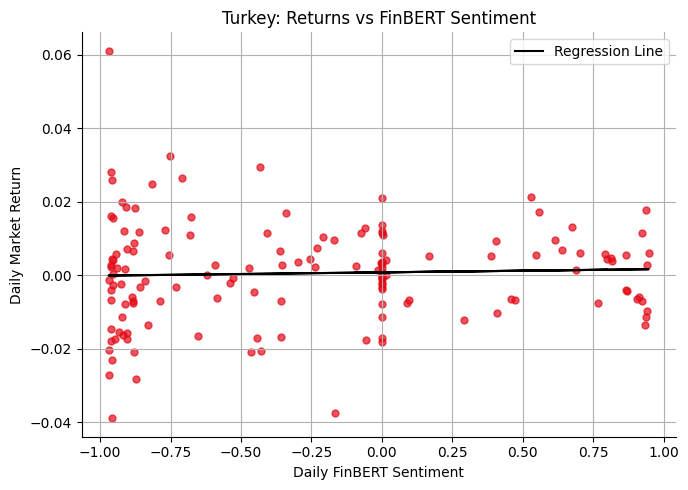


Turkey
----------------------------------------
Slope (β): 0.000897
Correlation: 0.0414


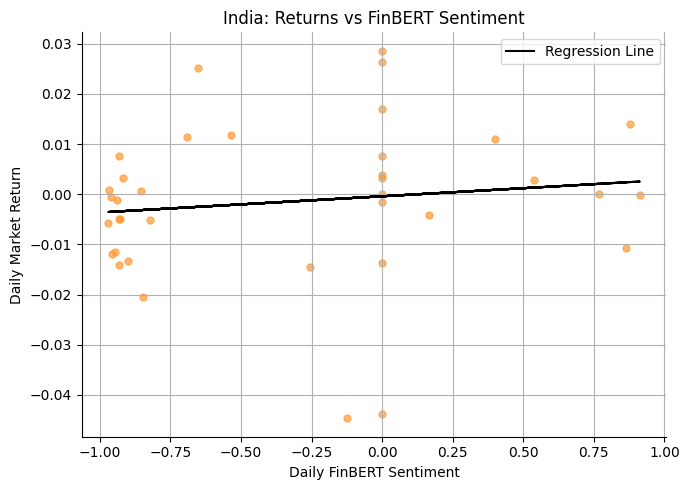


India
----------------------------------------
Slope (β): 0.003227
Correlation: 0.1284


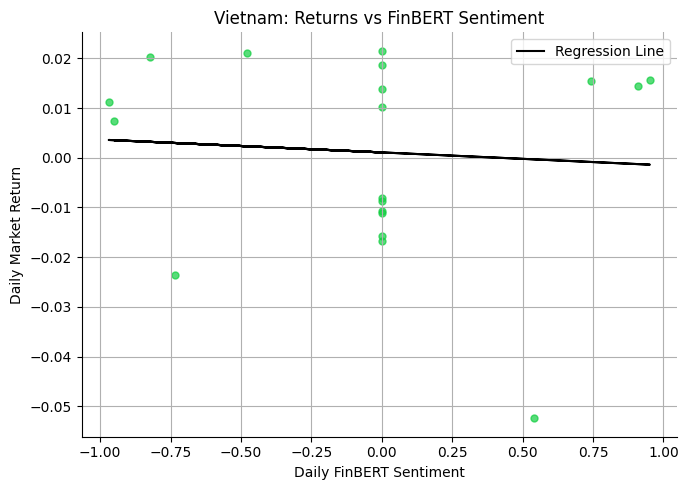


Vietnam
----------------------------------------
Slope (β): -0.002586
Correlation: -0.0745


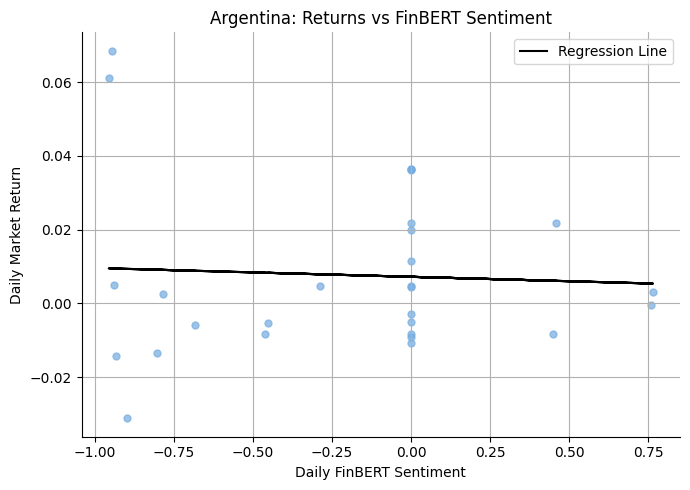


Argentina
----------------------------------------
Slope (β): -0.002393
Correlation: -0.0531


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3


returns = data.pct_change().dropna()

#NON-LAGGED! - Not used for blog.

conn = sqlite3.connect(DB_PATH)

df_finbert = pd.read_sql_query("""
SELECT date, country, sentiment_score_finbert
FROM articles
WHERE sentiment_score_finbert IS NOT NULL
""", conn)

conn.close()


df_finbert["date"] = pd.to_datetime(df_finbert["date"])



colors = {
    "Turkey": "#E30A17",
    "Vietnam": "#11CE40",
    "India": "#FF9933",
    "Argentina": "#74ACDF"
}

countries = ["Turkey", "India", "Vietnam", "Argentina"]



for country in countries:


    sentiment = (
        df_finbert[df_finbert["country"] == country]
        .groupby("date")["sentiment_score_finbert"]
        .mean()
        .reset_index()
    )

    sentiment.columns = ["date", "sentiment"]

    market = returns[[country]].reset_index()

    market.columns = ["date", "returns"]

    merged = pd.merge(
        sentiment,
        market,
        on="date",
        how="inner"
    )

  
    merged = merged.dropna()

    if len(merged) < 5:
        print(f"Not enough data for {country}")
        continue


    x = merged["sentiment"]
    y = merged["returns"]

    slope, intercept = np.polyfit(x, y, 1)

    regression_line = slope * x + intercept

    correlation = np.corrcoef(x, y)[0, 1]


    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        x,
        y,
        color=colors[country],
        alpha=0.7,
        s=25
    )

    # regression line
    ax.plot(
        x,
        regression_line,
        color="black",
        linestyle="-",
        linewidth=1.5,
        label="Regression Line"
    )


    ax.set_title(f"{country}: Returns vs FinBERT Sentiment")

    ax.set_xlabel("Daily FinBERT Sentiment")
    ax.set_ylabel("Daily Market Return")

    ax.grid(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{country}")
    print("-" * 40)
    print(f"Slope (β): {slope:.6f}")
    print(f"Correlation: {correlation:.4f}")

In [50]:
import pandas as pd
import numpy as np


lag_results = []

def compute_stats(x, y):

    corr = x.corr(y)
    r2 = corr ** 2

    return corr, r2


for country in countries:


    if country not in returns.columns:
        print(f"Skipping {country} (missing market returns)")
        continue


    sentiment_df = (
        df_finbert[df_finbert["country"] == country]
        .groupby("date")["sentiment_score_finbert"]
        .mean()
        .reset_index()
        .rename(columns={
            "sentiment_score_finbert": "sentiment"
        })
    )


    returns_df = returns[[country]].reset_index()

    returns_df.columns = ["date", "returns"]

    merged_lags = pd.merge(
        sentiment_df,
        returns_df,
        on="date",
        how="inner"
    ).dropna()


    if len(merged_lags) < 10:
        print(f"Skipping {country}: not enough data")
        continue


    for lag in range(0, 11):

        temp = merged_lags.copy()

        temp["sentiment_lag"] = (
            temp["sentiment"]
            .shift(lag)
        )

        temp_clean = temp.dropna()

        corr, r2 = compute_stats(
            temp_clean["sentiment_lag"],
            temp_clean["returns"]
        )

        lag_results.append({
            "country": country,
            "direction": "sentiment_leads_market",
            "lag": lag,
            "correlation": corr,
            "R2": r2
        })


    for lag in range(0, 11):

        temp = merged_lags.copy()

        temp["returns_lag"] = (
            temp["returns"]
            .shift(lag)
        )

        temp_clean = temp.dropna()

        corr, r2 = compute_stats(
            temp_clean["sentiment"],
            temp_clean["returns_lag"]
        )

        lag_results.append({
            "country": country,
            "direction": "market_leads_sentiment",
            "lag": lag,
            "correlation": corr,
            "R2": r2
        })


results_df = pd.DataFrame(lag_results)


print("\n=== FULL RESULTS ===")

print(
    results_df.sort_values(
        by="correlation",
        ascending=False
    )
)


print("\n=== BEST LAG BY COUNTRY ===")

best_lags = (
    results_df.iloc[
        results_df.groupby("country")["correlation"]
        .apply(lambda x: x.abs().idxmax())
    ]
)

print(best_lags)

for _, row in best_lags.iterrows():

    print("\n" + "=" * 40)

    print(f"Country: {row['country']}")

    print(f"Best Direction: {row['direction']}")

    print(f"Best Lag: {row['lag']} days")

    print(f"Correlation: {row['correlation']:.4f}")

    print(f"R²: {row['R2']:.4f}")


=== FULL RESULTS ===
      country               direction  lag  correlation        R2
50    Vietnam  sentiment_leads_market    6     0.500504  0.250505
32      India  sentiment_leads_market   10     0.389184  0.151464
51    Vietnam  sentiment_leads_market    7     0.382764  0.146508
63    Vietnam  market_leads_sentiment    8     0.364708  0.133012
65    Vietnam  market_leads_sentiment   10     0.350042  0.122530
..        ...                     ...  ...          ...       ...
47    Vietnam  sentiment_leads_market    3    -0.395451  0.156381
82  Argentina  market_leads_sentiment    5    -0.405238  0.164218
62    Vietnam  market_leads_sentiment    7    -0.428281  0.183425
52    Vietnam  sentiment_leads_market    8    -0.430426  0.185267
46    Vietnam  sentiment_leads_market    2    -0.473056  0.223782

[88 rows x 5 columns]

=== BEST LAG BY COUNTRY ===
      country               direction  lag  correlation        R2
82  Argentina  market_leads_sentiment    5    -0.405238  0.164218
32

In [35]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN article_text TEXT
    """)

    conn.commit()
    print("article_text column created.")

except sqlite3.OperationalError:
    print("article_text column already exists.")

conn.close()

article_text column already exists.


In [36]:
import sqlite3
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

df_articles = pd.read_sql_query("""
SELECT article_id, url
FROM articles
WHERE url IS NOT NULL
AND article_text IS NULL
""", conn)

print(f"Articles with missing body text: {len(df_articles)}")

headers = {
    "User-Agent": "Mozilla/5.0"
}

def scrape_article_text(url):
    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=10
        )

        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, "html.parser")
        paragraphs = soup.find_all("p")

        text = " ".join(
            p.get_text(strip=True)
            for p in paragraphs
        )

        if len(text) < 200:
            return None

        return text

    except Exception as e:
        print(f"Scrape failed: {e}")
        return None

if not RUN_ARTICLE_BODY_SCRAPING:
    print("Article-body scraping is disabled; using cached article_text values.")
else:
    success = 0
    failed = 0

    for _, row in df_articles.iterrows():
        article_id = row["article_id"]
        url = row["url"]

        print(f"Scraping: {url}")
        text = scrape_article_text(url)

        if text is not None:
            cursor.execute("""
            UPDATE articles
            SET article_text = ?
            WHERE article_id = ?
            """, (text, article_id))
            success += 1
        else:
            failed += 1

        time.sleep(1)

    conn.commit()

    print("\nscraping complete")
    print(f"Success: {success}")
    print(f"Failed: {failed}")

conn.close()

Articles with missing body text: 114
Article-body scraping is disabled; using cached article_text values.


In [37]:
# Use conn.close() if previous cell did not finish to prevent 'datebase locked'.

In [46]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_fulltext_finbert REAL
    """)
    conn.commit()
except sqlite3.OperationalError:
    print("Column already exists.")

df_articles = pd.read_sql_query("""
SELECT article_id, article_text
FROM articles
WHERE article_text IS NOT NULL
  AND sentiment_fulltext_finbert IS NULL
""", conn)

if df_articles.empty:
    print("No missing full-text FinBERT sentiment scores to compute.")
elif not RECOMPUTE_MISSING_FINBERT:
    print(f"{len(df_articles)} missing full-text FinBERT scores found, but recomputation is disabled.")
else:
    from transformers import pipeline
    finbert = pipeline(
        "sentiment-analysis",
        model="ProsusAI/finbert"
    )

    def finbert_signed(text):
        try:
            text = text[:2000]
            result = finbert(text)[0]
            label = result["label"]
            score = result["score"]

            if label == "positive":
                return score
            elif label == "negative":
                return -score
            else:
                return 0.0

        except Exception:
            return None

    df_articles["sentiment_fulltext_finbert"] = (
        df_articles["article_text"]
        .apply(finbert_signed)
    )

    cursor.executemany("""
    UPDATE articles
    SET sentiment_fulltext_finbert = ?
    WHERE article_id = ?
    """, list(zip(
        df_articles["sentiment_fulltext_finbert"],
        df_articles["article_id"]
    )))

    conn.commit()
    print(f"Updated {len(df_articles)} full-text FinBERT sentiment scores.")

conn.close()

Column already exists.
2 missing full-text FinBERT scores found, but recomputation is disabled.


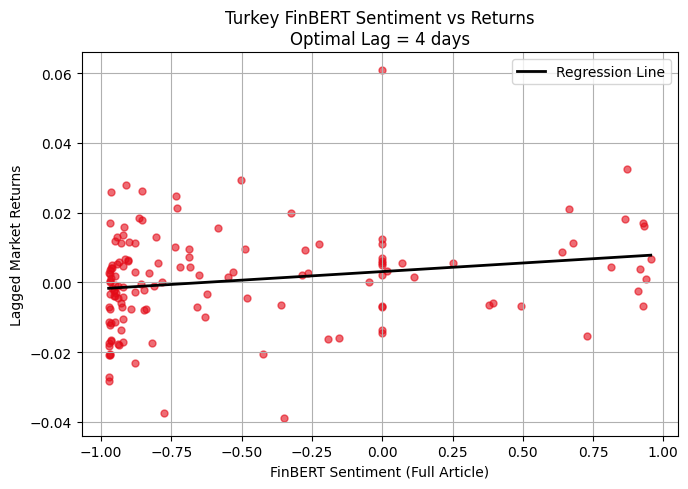


Turkey
--------------------------------------------------
Optimal Lag: 4 days
Correlation: 0.2073
R²: 0.0430
Slope (β): 0.004920
Positive relationship detected


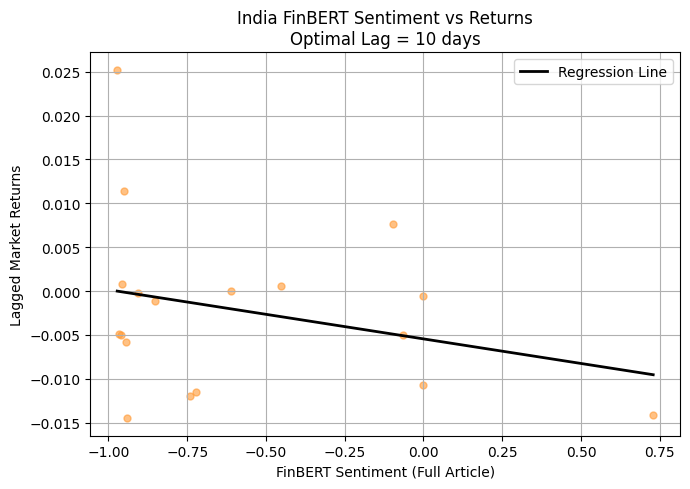


India
--------------------------------------------------
Optimal Lag: 10 days
Correlation: -0.2803
R²: 0.0786
Slope (β): -0.005602
Negative relationship detected


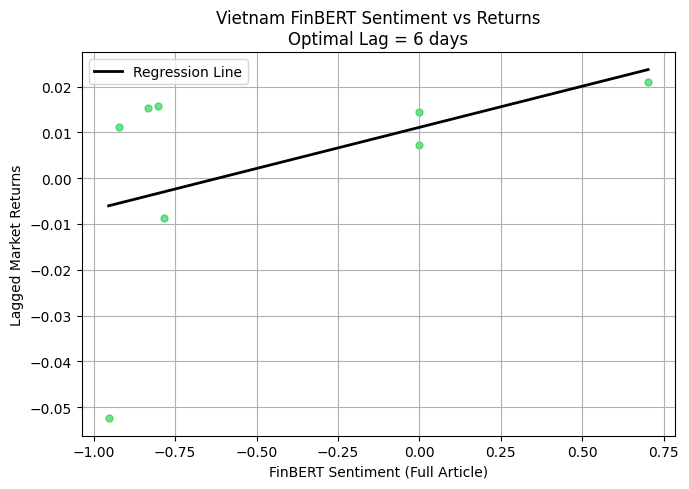


Vietnam
--------------------------------------------------
Optimal Lag: 6 days
Correlation: 0.4533
R²: 0.2055
Slope (β): 0.017970
Positive relationship detected


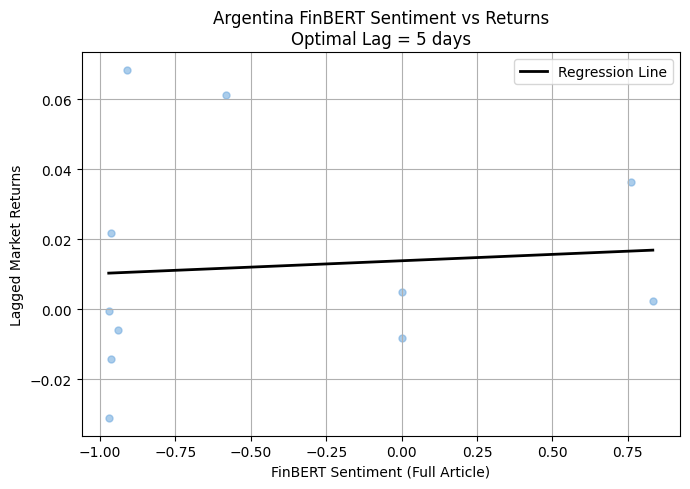


Argentina
--------------------------------------------------
Optimal Lag: 5 days
Correlation: 0.0824
R²: 0.0068
Slope (β): 0.003647
Positive relationship detected


In [ ]:
#for web scraped article contents
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

best_lags = {
    "Turkey": 4,
    "India": 10,
    "Vietnam": 6,
    "Argentina": 5
}


countries = ["Turkey", "India", "Vietnam", "Argentina"]


colors = {
    "Turkey": "#E30A17",
    "India": "#FF9933",
    "Vietnam": "#11CE40",
    "Argentina": "#74ACDF"
}


conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""

SELECT
    date,
    country,
    sentiment_fulltext_finbert

FROM articles

WHERE sentiment_fulltext_finbert IS NOT NULL

""", conn)

conn.close()


df["date"] = pd.to_datetime(df["date"])


for country in countries:


    BEST_LAG = best_lags[country]


    sentiment = (
        df[df["country"] == country]
        .groupby("date")["sentiment_fulltext_finbert"]
        .mean()
        .reset_index()
    )

    sentiment.columns = ["date", "sentiment"]


    if country not in returns.columns:
        print(f"Skipping {country} (missing in returns)")
        continue

    market = returns[[country]].reset_index()

    market.columns = ["date", "returns"]


    merged = pd.merge(
        sentiment,
        market,
        on="date",
        how="inner"
    ).dropna()


    if len(merged) < 10:
        print(f"Not enough data for {country}")
        continue


    merged["returns_lagged"] = (
        merged["returns"]
        .shift(BEST_LAG)
    )


    final = merged[
        ["sentiment", "returns_lagged"]
    ].dropna()

    x = final["sentiment"]
    y = final["returns_lagged"]


    slope, intercept = np.polyfit(x, y, 1)

    correlation = np.corrcoef(x, y)[0, 1]

    r2 = correlation ** 2

    x_sorted = np.sort(x)

    regression_line = (
        slope * x_sorted + intercept
    )


    plt.figure(figsize=(7, 5))

    plt.scatter(
        x,
        y,
        color=colors[country],
        alpha=0.6,
        s=25
    )

    plt.plot(
        x_sorted,
        regression_line,
        color="black",
        linewidth=2,
        label="Regression Line"
    )


    plt.title(
        f"{country} FinBERT Sentiment vs Returns"
        f"\nOptimal Lag = {BEST_LAG} days"
    )

    plt.xlabel(
        "FinBERT Sentiment (Full Article)"
    )

    plt.ylabel(
        "Lagged Market Returns"
    )


    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()


    print("\n" + "=" * 50)

    print(country)

    print("-" * 50)

    print(f"Optimal Lag: {BEST_LAG} days")

    print(f"Correlation: {correlation:.4f}")

    print(f"R²: {r2:.4f}")

    print(f"Slope (β): {slope:.6f}")

  
    if correlation > 0:
        print("Positive relationship detected")

    elif correlation < 0:
        print("Negative relationship detected")

    else:
        print("No relationship detected")